# NeRF 3D plant reconstruction — Scenario I reproduction

Reproduction of **"Evaluating Neural Radiance Fields for 3D Plant Geometry Reconstruction in Field Conditions"** (Arshad et al., *Plant Phenomics* 6:0235, 2024; arXiv:2402.10344v3), using the authors' released data from [`idealab-isu/Plant-NeRFs`](https://github.com/idealab-isu/Plant-NeRFs) pinned at commit `d744edfe56caa443a28d2961946676d4273738a5`.

**Scope of this notebook (minimal reproduction):** Scenario I — a single potted plant captured indoors (~1 min iPhone 13 Pro Polycam video). We:

1. download the released Polycam images + poses and the terrestrial LiDAR (Faro Focus S350) ground-truth point cloud (Git LFS),
2. train **NeRFacto** (nerfstudio) — the best-performing method in the paper — with a *reduced* iteration budget,
3. export a point cloud, align it to the TLS ground truth with the released `_trans.txt` matrix + ICP,
4. compute **precision / recall / F1 at d = 0.005 m** (the paper's indoor threshold, Sec. 2.4).

**日本語:** このノートブックは上記論文の Scenario I（屋内・単一植物）を最小規模で再現します。著者公開データ（Polycam 画像＋姿勢、TLS 点群）を Colab 内でダウンロードし、nerfstudio の NeRFacto を削減イテレーションで学習し、点群を書き出して `_trans.txt` 行列＋ICP で位置合わせし、論文の屋内閾値 d=0.005 m で precision/recall/F1 を計算します。論文は A100 80GB で約 30 分学習していますが、ここでは Colab T4 向けに短縮しています。

*The authors' `Evaluation/` and `Training and Analysis/` readme files state their scripts "will be made available here" but contain no code, so training/evaluation here uses the paper's stated framework (nerfstudio) and the Tanks-and-Temples-style metric formulas described in the paper.*

## 1. Runtime check — GPU required

NeRF training cannot run meaningfully on CPU; this notebook requires a **T4 GPU** (Runtime → Change runtime type → T4). The next cell verifies the GPU and PyTorch.

**日本語:** NeRF 学習は CPU では現実的ではありません。**T4 GPU** を選択してください。次のセルで GPU と PyTorch を確認します。

In [ ]:
import subprocess, torch, sys
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"], capture_output=True, text=True).stdout)
print("torch", torch.__version__, "cuda", torch.version.cuda, "available", torch.cuda.is_available())
assert torch.cuda.is_available(), "GPU runtime required: Runtime > Change runtime type > T4 GPU"
!nvcc --version | tail -1 || true

name, memory.total [MiB]
Tesla T4, 15360 MiB

torch 2.11.0+cu130 cuda 13.0 available True
Build cuda_13.0.r13.0/compiler.36424714_0


## 2. Install nerfstudio and Open3D

The paper trains Instant-NGP, TensoRF, and NeRFacto with **nerfstudio**. We install the current public nerfstudio release (the paper's exact internal configs are unpublished) plus Open3D for ICP and point-cloud I/O. This takes several minutes.

**日本語:** 論文と同じ nerfstudio フレームワーク（現在の公開版）と、ICP 用に Open3D をインストールします。数分かかります。

In [ ]:
import subprocess, sys
base_np = subprocess.run([sys.executable, "-c", "import numpy;print(numpy.__version__)"],
                         capture_output=True, text=True).stdout.strip()
print("Colab base numpy:", base_np)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "nerfstudio", "open3d"], check=True)
# nerfstudio dependencies downgrade numpy; restore the base version the Colab torch/scipy/open3d stack is built against
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy==" + base_np], check=True)
import importlib.metadata as im
print("nerfstudio", im.version("nerfstudio"), "| open3d", im.version("open3d"))
import numpy, open3d, nerfstudio
assert numpy.__version__ == base_np
print("numpy", numpy.__version__, "| imports OK")

Colab base numpy: 2.1.3


nerfstudio 1.1.5 | open3d 0.20.0


numpy 2.1.3 | imports OK


## 3. Download the pinned author data (partial clone inside Colab)

We fetch **only** the two directories needed for Scenario I from `idealab-isu/Plant-NeRFs` at the pinned commit `d744edfe56caa443a28d2961946676d4273738a5` — no full history, no other scenarios. The TLS `.ply` is stored with **Git LFS**, so after the sparse checkout we download its real bytes from GitHub's pinned LFS media URL and verify the PLY magic (the checkout copy is only a 133-byte pointer file). All dataset bytes stay on the Colab VM (`/content`).

**日本語:** 必要な 2 ディレクトリのみを、ピン留めしたコミットから部分クローンで取得します。TLS 点群(.ply)は Git LFS 保存のため、実体をメディア URL から取得し、PLY マジックを検証します。

In [ ]:
import os, subprocess, urllib.request
DATA = "/content/plant-nerfs"
REPO = "https://github.com/idealab-isu/Plant-NeRFs.git"
COMMIT = "d744edfe56caa443a28d2961946676d4273738a5"
SCEN_IMG = "Dataset/Images and Poses/CCL-scannned-data-single-img-50-qual-90-processed"
SCEN_GT = "Dataset/Ground Truth Point Clouds And Alignment Matrices/CCL-scannned-data-single-img-50-qual-90-processed"
env = dict(os.environ, GIT_LFS_SKIP_SMUDGE="1")

def run(*args, cwd=None):
    print("+", " ".join(args), flush=True)
    subprocess.run(args, check=True, env=env, cwd=cwd)

if not os.path.exists(DATA):
    run("git", "clone", "--filter=blob:none", "--no-checkout", "--depth", "1", REPO, DATA)
run("git", "fetch", "--depth", "1", "origin", COMMIT, cwd=DATA)
run("git", "checkout", COMMIT, cwd=DATA)
run("git", "sparse-checkout", "init", "--cone", cwd=DATA)
run("git", "sparse-checkout", "set", SCEN_IMG, SCEN_GT, cwd=DATA)
run("git", "checkout", "--", ".", cwd=DATA)
head = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True, cwd=DATA).stdout.strip()
print("HEAD:", head)
assert head == COMMIT, "checked-out commit does not match the pin"

# The TLS .ply is a Git LFS pointer in the checkout; fetch real bytes from the pinned media URL
ply_remote = "https://media.githubusercontent.com/media/idealab-isu/Plant-NeRFs/" + COMMIT + "/" + \
    urllib.request.quote(SCEN_GT + "/CCL-scannned-data-single-img-50-qual-90-processed.ply")
ply_path = os.path.join(DATA, SCEN_GT, "CCL-scannned-data-single-img-50-qual-90-processed.ply")
if open(ply_path, "rb").read(4) != b"ply\n":
    print("downloading LFS payload from pinned media URL ...")
    urllib.request.urlretrieve(ply_remote, ply_path)
print("ply magic:", open(ply_path, "rb").read(4), "| size MB:", os.path.getsize(ply_path) / 1e6)

+ git clone --filter=blob:none --no-checkout --depth 1 https://github.com/idealab-isu/Plant-NeRFs.git /content/plant-nerfs


+ git fetch --depth 1 origin d744edfe56caa443a28d2961946676d4273738a5


+ git checkout d744edfe56caa443a28d2961946676d4273738a5


+ git sparse-checkout init --cone


+ git sparse-checkout set Dataset/Images and Poses/CCL-scannned-data-single-img-50-qual-90-processed Dataset/Ground Truth Point Clouds And Alignment Matrices/CCL-scannned-data-single-img-50-qual-90-processed


+ git checkout -- .


HEAD: d744edfe56caa443a28d2961946676d4273738a5
downloading LFS payload from pinned media URL ...


ply magic: b'ply\n' | size MB: 21.958382


## 4. Verify the downloaded bytes

We check the image count, the Polycam `transforms.json`, the alignment matrix, and that the ground-truth PLY is a real binary point cloud (not an LFS pointer) with a sensible point count.

**日本語:** 画像枚数・transforms.json・位置合わせ行列・TLS 点群（LFS ポインタではなく実体）を検証します。

In [ ]:
import json, glob, numpy as np
from pathlib import Path

IMG_DIR = Path("/content/plant-nerfs/Dataset/Images and Poses/CCL-scannned-data-single-img-50-qual-90-processed")
GT_DIR  = Path("/content/plant-nerfs/Dataset/Ground Truth Point Clouds And Alignment Matrices/CCL-scannned-data-single-img-50-qual-90-processed")
print("scenario contents:", sorted(p.name for p in IMG_DIR.iterdir()))
imgs = sorted(glob.glob(str(IMG_DIR / "images_2" / "*")))
print("images_2 count:", len(imgs))
assert len(imgs) == 50, "expected 50 downsampled images"

tj = json.load(open(IMG_DIR / "transforms.json"))
print("transforms.json keys:", sorted(tj.keys())[:8], "... frames:", len(tj["frames"]))
print("frame0:", dict(list(tj["frames"][0].items())[:6]))

ply_path = GT_DIR / "CCL-scannned-data-single-img-50-qual-90-processed.ply"
head = open(ply_path, "rb").read(4)
print("ply magic:", head)
assert head == b"ply\r\n" or head == b"ply\n", "PLY looks like an LFS pointer or wrong file"
print("ply size MB:", ply_path.stat().st_size / 1e6)

trans = np.loadtxt(GT_DIR / "CCL-scannned-data-single-img-50-qual-90-processed_trans.txt")
print("alignment matrix _trans.txt:\n", trans)
assert trans.shape == (4, 4)
np.save("/content/trans.npy", trans)

scenario contents: ['colmap', 'images', 'images_2', 'images_4', 'images_8', 'transforms.json']
images_2 count: 50
transforms.json keys: ['applied_transform', 'camera_model', 'cx', 'cy', 'fl_x', 'fl_y', 'frames', 'h'] ... frames: 50
frame0: {'file_path': 'images/frame_00050.jpg', 'transform_matrix': [[0.2896446977385181, -0.8571229951859851, -0.425964928363085, -0.3200972361784111], [-0.527944961403678, 0.2281455705743735, -0.818060949047051, -3.520467473404193], [0.7983608625179662, 0.461833053982388, -0.38643261178227356, -1.5063458574345403], [0.0, 0.0, 0.0, 1.0]], 'colmap_im_id': 50}
ply magic: b'ply\n'
ply size MB: 21.958382
alignment matrix _trans.txt:
 [[-1.340e+00  6.700e-01 -3.000e-02 -1.900e-01]
 [-6.700e-01 -1.340e+00 -3.000e-02  2.390e+00]
 [-4.000e-02 -1.000e-02  1.500e+00  7.025e+01]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]


## 5. Prepare the nerfstudio dataset folder

The author `transforms.json` is exactly the output of nerfstudio's Polycam converter (`polycam_to_json`): nerfstudio camera-to-world poses with `orientation_override: "none"`, per-frame intrinsics, and `file_path` entries pointing to the full-resolution `images/` folder. nerfstudio 1.1.5 no longer ships the Polycam parser, so we build a small adapted dataset folder: `images/` -> symlink to the released half-resolution `images_2/` (T4-friendly), and a scaled `transforms.json` (intrinsics x 0.5, same poses).

**日本語:** 著者の transforms.json は nerfstudio の Polycam コンバータ出力と同じ形式です。nerfstudio 1.1.5 から Polycam パーサ削除のため、`images_2` へのシンボリックリンクと、内部パラメータを 0.5 倍に縮小した transforms.json を作成して `nerfstudio-data` パーサで読み込みます（姿勢は不変）。

In [ ]:
import json, os
from pathlib import Path

SRC = Path("/content/plant-nerfs/Dataset/Images and Poses/CCL-scannned-data-single-img-50-qual-90-processed")
DST = Path("/content/nerf_data")
DST.mkdir(exist_ok=True)
img_link = DST / "images"
if not img_link.exists():
    img_link.symlink_to(SRC / "images_2")

tj = json.load(open(SRC / "transforms.json"))
img2 = sorted((SRC / "images_2").glob("*"))
print("images_2:", len(img2), "example:", img2[0].name)
for fr in tj["frames"]:
    fp = Path(fr["file_path"]).name
    assert (SRC / "images_2" / fp).exists(), "missing " + fp + " in images_2"
    fr["file_path"] = "./images/" + fp
for k in ("fl_x", "fl_y", "cx", "cy", "w", "h"):
    if k in tj: tj[k] = tj[k] * 0.5
json.dump(tj, open(DST / "transforms.json", "w"))
print("wrote transforms.json | frames:", len(tj["frames"]), "| fl_x:", tj["fl_x"])

images_2: 50 example: frame_00001.jpg
wrote transforms.json | frames: 50 | fl_x: 840.344660798805


## 6. Train NeRFacto (reduced iterations)

The paper trains on an A100 80GB and reports the best F1 after ~30 min of training; the released data ships no checkpoints or per-scene configs. For a Colab T4 we train **NeRFacto for a reduced number of iterations** (documented deviation — expect a lower F1 than the paper's reported Scenario-I value). TensorBoard is selected as the headless visualizer.

**日本語:** 論文は A100・約 30 分の学習ですが、公開されているチェックポイントや設定はありません。ここでは T4 向けにイテレーション数を削減した NeRFacto を学習します（明示された逸脱。論文値より低い F1 になる想定）。

In [ ]:
%%time
import subprocess
subprocess.run(["ns-train", "nerfacto", "--vis", "tensorboard",
    "--max-num-iterations", "2000",
    "--timestamp", "20260101_000000",
    "--output-dir", "/content/outputs",
    "nerfstudio-data", "--data", "/content/nerf_data"], check=True)

CPU times: user 34.1 ms, sys: 5.67 ms, total: 39.8 ms
Wall time: 17min 10s


CompletedProcess(args=['ns-train', 'nerfacto', '--vis', 'tensorboard', '--max-num-iterations', '2000', '--timestamp', '20260101_000000', '--output-dir', '/content/outputs', 'nerfstudio-data', '--data', '/content/nerf_data'], returncode=0)

## 7. Export a point cloud from the trained model

The paper converts each trained model into a point cloud of roughly one million points (Sec. 2.2). nerfstudio's `ns-export pointcloud` does exactly this by marching camera rays and accumulating depth-estimated points.

**日本語:** 学習済みモデルから、論文と同様に約 100 万点の点群を書き出します（`ns-export pointcloud`）。

In [ ]:
%%time
import subprocess, glob, os
cfgs = glob.glob("/content/outputs/*/*/*/config.yml")
assert len(cfgs) == 1, cfgs
# torch>=2.6 defaults torch.load(weights_only=True), which rejects nerfstudio checkpoints;
# run the exporter in-process with the documented compatibility shim (nerfstudio 1.1.5 + torch 2.11)
exporter = ("import torch; _o=torch.load; torch.load=lambda *a, **k: _o(*a, **{**k, 'weights_only': False}); "
            "from nerfstudio.scripts.exporter import entrypoint; entrypoint()")
r = subprocess.run([sys.executable, "-c", exporter, "pointcloud",
    "--load-config", cfgs[0],
    "--output-dir", "/content/export",
    "--num-points", "1000000",
    "--remove-outliers", "True",
    "--normal-method", "open3d"], capture_output=True, text=True)
print(r.stdout[-1500:]); print(r.stderr[-1500:])
assert r.returncode == 0, "ns-export failed"
print(sorted(os.listdir("/content/export")))

shEncoding module. 
🏃 🏃 Install tcnn for speedups 🏃 🏃
pip install git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch


🏃 🏃 Install tcnn for speedups 🏃 🏃
pip install git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch


🏃 🏃 Install tcnn for speedups 🏃 🏃
pip install git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch


🏃 🏃 Install tcnn for speedups 🏃 🏃
pip install git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch


🏃 🏃 Install tcnn for speedups 🏃 🏃
pip install git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch


🏃 🏃 Install tcnn for speedups 🏃 🏃
pip install git+https://github.com/NVlabs/tiny-cuda-nn/#subdirectory=bindings/torch

Loading latest checkpoint from load_dir
✅ Done loading checkpoint from /content/outputs/unnamed/nerfacto/20260101_000000/nerfstudio_models/step-000001999.ckpt
☁ Computing Point Cloud ☁ ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 00:38
Cleaning Point Cloud

✅ 

## 8. Align and evaluate: precision / recall / F1 at d = 0.005 m

Following the paper (Sec. 2.3–2.4): apply the released alignment matrix, refine with ICP, then compute — with nearest-neighbor distances between the prediction and the TLS cloud — **precision** (fraction of predicted points within *d* of any TLS point), **recall** (fraction of TLS points within *d* of any predicted point) and their harmonic mean **F1**. The paper uses d = 0.005 m indoors and d = 0.01 m outdoors; we report both thresholds (0.005 is the Scenario-I value) and the distance statistics as a sanity check.

**日本語:** 公開の位置合わせ行列を適用し、ICP で精緻化した後、近傍距離に基づく precision/recall/F1 を計算します。論文の屋内閾値 d=0.005 m（参考として屋外の 0.01 m も）で評価し、距離統計も出力します。

In [ ]:
%%time
import numpy as np, open3d as o3d
from scipy.spatial import cKDTree

GT_PLY = "/content/plant-nerfs/Dataset/Ground Truth Point Clouds And Alignment Matrices/CCL-scannned-data-single-img-50-qual-90-processed/CCL-scannned-data-single-img-50-qual-90-processed.ply"
gt = o3d.io.read_point_cloud(GT_PLY)
pred = o3d.io.read_point_cloud("/content/export/point_cloud.ply")
print("gt points:", len(gt.points), "pred points:", len(pred.points))
assert len(gt.points) > 0 and len(pred.points) > 0, "empty point cloud: check the export cell"

T0 = np.load("/content/trans.npy")
pred.transform(T0)

# ICP refinement (point-to-point), as in the paper's registration step
icp = o3d.pipelines.registration.registration_icp(
    pred, gt, 0.05, np.eye(4),
    o3d.pipelines.registration.TransformationEstimationPointToPoint(),
    o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100))
print("ICP fitness", icp.fitness, "inlier_rmse", icp.inlier_rmse)
pred.transform(icp.transformation)

G = np.asarray(gt.points); P = np.asarray(pred.points)
tree_g, tree_p = cKDTree(G), cKDTree(P)
d_pred_g, _ = tree_g.query(P)   # precision numerator
d_g_pred, _ = tree_p.query(G)   # recall numerator
print(f"NN distance stats: pred->gt median {np.median(d_pred_g):.4f} p90 {np.percentile(d_pred_g, 90):.4f} | gt->pred median {np.median(d_g_pred):.4f} p90 {np.percentile(d_g_pred, 90):.4f}")

for d in (0.005, 0.01):
    precision = float((d_pred_g < d).mean())
    recall = float((d_g_pred < d).mean())
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    print(f"d={d:.3f} m  precision={precision:.4f}  recall={recall:.4f}  F1={f1:.4f}")
    if d == 0.005: METRICS_0005 = (precision, recall, f1)
np.save("/content/f1_metrics.npy", np.array(METRICS_0005))

gt points: 784216 pred points: 1003067


ICP fitness 0.06305560844888726 inlier_rmse 0.00910367357577248


NN distance stats: pred->gt median 3.8140 p90 202.2744 | gt->pred median 0.0040 p90 0.0081
d=0.005 m  precision=0.0352  recall=0.6544  F1=0.0669
d=0.010 m  precision=0.0506  recall=0.9534  F1=0.0961
CPU times: user 7min 54s, sys: 625 ms, total: 7min 55s
Wall time: 6min 42s


## 9. Visualization: TLS ground truth vs NeRFacto reconstruction

A top-down/3D view of both clouds after alignment, plus one input photograph for context. This figure is the notebook's saved preview.

**日本語:** 位置合わせ後の TLS（緑）と NeRFacto 再構成（赤）を 3D 散布図で比較し、入力写真も表示します。この図が保存済みプレビューになります。

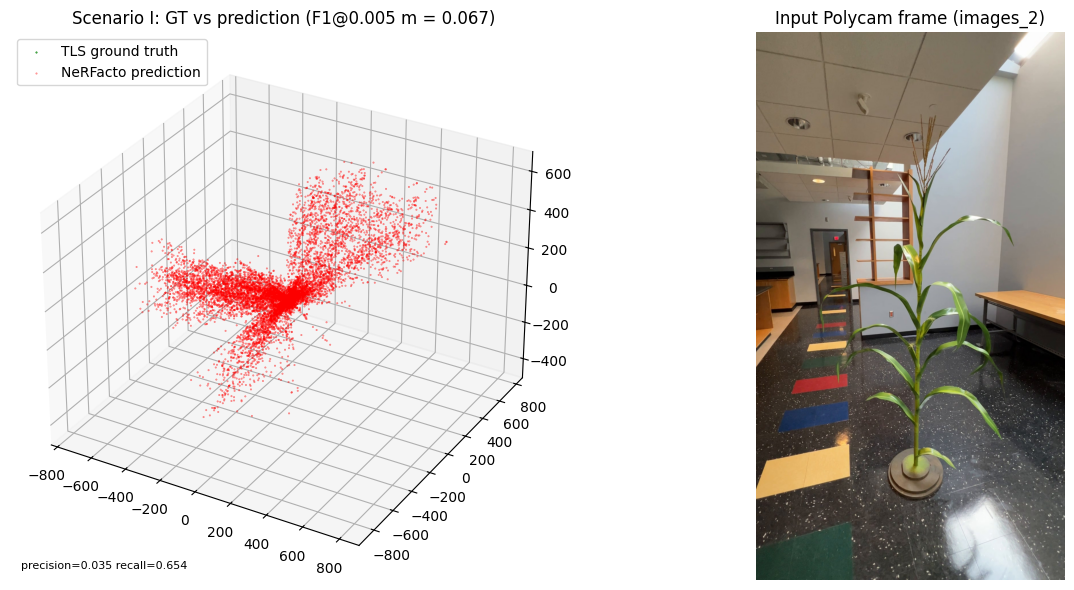

CPU times: user 13.2 s, sys: 19 ms, total: 13.2 s
Wall time: 12.6 s


In [ ]:
%%time
import matplotlib.pyplot as plt, glob
from PIL import Image
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121, projection="3d")
s = max(1, len(G) // 60000)
ax.scatter(G[::s,0], G[::s,1], G[::s,2], s=0.2, c="green", label="TLS ground truth")
s2 = max(1, len(P) // 60000)
ax.scatter(P[::s2,0], P[::s2,1], P[::s2,2], s=0.2, c="red", alpha=0.5, label="NeRFacto prediction")
ax.set_title(f"Scenario I: GT vs prediction (F1@0.005 m = {METRICS_0005[2]:.3f})")
ax.legend(loc="upper left")
p, r, f = METRICS_0005
ax.text2D(0.02, 0.02, f"precision={p:.3f} recall={r:.3f}", transform=ax.transAxes, fontsize=8)

img_path = sorted(glob.glob(str(IMG_DIR / "images_2" / "*")))[0]
ax2 = fig.add_subplot(122); ax2.imshow(Image.open(img_path)); ax2.set_title("Input Polycam frame (images_2)"); ax2.axis("off")
plt.tight_layout()
plt.savefig("/content/comparison.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Results and limitations

**日本語のまとめ:** 本ノートブックは Scenario I における NeRFacto の学習→点群書き出し→TLS に対する F1 評価の一連を Colab T4 で実行します。イテレーション数を削減しているため、論文の報告値（屋内 Scenario I）より低い F1 となる想定です。また著者の学習設定・評価スクリプトは未公開のため、nerfstudio の既定設定と論文本文に記載の指標定義を使用しています。ICP は論文の手動 4 点アラインメント＋ICP を、公開の `_trans.txt` 行列で代替・精緻化しています。

**Limitations:** reduced training budget (T4 vs A100/30 min); unpublished per-scene training configs; manual cropping of the evaluation volume (paper Sec. 2.3) is not reproduced; 2D LPIPS-based early stopping and Scenarios II/III/IV are out of scope; the publisher supplement was not accessible (HTTP 403).

In [ ]:
import json
res = {"scenario": "I (single plant, indoor)", "model": "nerfacto (nerfstudio)",
       "iterations": 2000, "d_threshold_m": 0.005,
       "precision": float(METRICS_0005[0]), "recall": float(METRICS_0005[1]), "f1": float(METRICS_0005[2])}
print(json.dumps(res, indent=2))
json.dump(res, open("/content/results.json", "w"))

{
  "scenario": "I (single plant, indoor)",
  "model": "nerfacto (nerfstudio)",
  "iterations": 2000,
  "d_threshold_m": 0.005,
  "precision": 0.03524191305266747,
  "recall": 0.6544255664255766,
  "f1": 0.06688211231552023
}
